# lapanda Python Learning Tutorial

This notebook shows a minimal parameter-learning workflow. We define a small nonlinear constrained problem in CasADi, solve it with lapanda, differentiate an outer imitation loss through the solution, and update the learnable parameter vector `theta`.

In [1]:
import casadi as ca
import matplotlib.pyplot as plt
import numpy as np

from lapanda import AlmOptions, BackwardOptions, CasadiProblem, SolverOptions, build_solver

## Define a Constrained Inner Problem

The inner problem chooses a two-dimensional decision vector `u`. The parameter `theta` shifts the optimizer, while the variable input stores the demonstration target used by the outer loss.

In [2]:
u = ca.SX.sym("u", 2)
theta_sym = ca.SX.sym("theta", 2)
demo_sym = ca.SX.sym("demo", 2)

cost = 0.5 * ca.sumsqr(u - theta_sym) + 0.02 * ca.sumsqr(u)
outer_loss = 0.5 * ca.sumsqr(u - demo_sym)
constraints = ca.vertcat(
    u[0] ** 2 + u[1] ** 2 - 1.0,
    u[0] + u[1] - 0.65,
)

problem = CasadiProblem(
    u=u,
    theta=theta_sym,
    variable=demo_sym,
    cost=cost,
    box_lower=np.array([-1.5, -1.5]),
    box_upper=np.array([1.5, 1.5]),
    constraints=constraints,
    outer_loss=outer_loss,
)

constraint_fun = ca.Function("constraint_fun", [u], [constraints])

## Build the Solver

The default `compiled` backend generates a CasADi C oracle and builds it with CMake. For small debugging examples, you can set `backend="callback"`.

In [3]:
solver = build_solver(problem, backend="compiled", name="tutorial_learning_oracle")

inner = SolverOptions()
inner.max_iterations = 1500
inner.tolerance = 1e-4
inner.buffer_size = 10
inner.max_stable_iter = 80

alm = AlmOptions()
alm.max_iterations = 20
alm.tolerance = 1e-4
alm.initial_penalty = 10.0
alm.penalty_update_factor = 5.0
alm.sufficient_decrease_factor = 0.25
alm.warm_start_inner = True

backward = BackwardOptions()
backward.enable = True
backward.tolerance = 1e-4
backward.max_iterations = 200

constraint_lower = np.array([-1e20, -1e20])
constraint_upper = np.array([0.0, 0.0])

## Generate a Demonstration

Here the demonstration is the solution produced by a teacher parameter. In a real application this target could come from an expert trajectory or recorded controller.

In [4]:
theta_teacher = np.array([0.85, -0.10])
demo_placeholder = np.zeros(2)

teacher = solver.solve_lapanda(
    x0=np.zeros(2),
    theta=theta_teacher,
    variable=demo_placeholder,
    constraint_lower=constraint_lower,
    constraint_upper=constraint_upper,
    inner_solver_options=inner,
    alm_options=alm,
    backward_options=backward,
)
demo = np.asarray(teacher["solution"], dtype=float)
demo

array([ 0.78173952, -0.13173237])

## Learn `theta` from the Demonstration

Each iteration solves the inner constrained problem, obtains `dL/dtheta`, and updates `theta` with a small gradient step. The primal solution, multipliers, and penalty are warm-started across learning iterations.

In [5]:
theta = np.array([-0.35, 0.75])
x0 = np.zeros(2)
multipliers = None
penalty = None

lr = 0.4
epochs = 40
history = []

for epoch in range(epochs + 1):
    result = solver.solve_lapanda(
        x0=x0,
        theta=theta,
        variable=demo,
        constraint_lower=constraint_lower,
        constraint_upper=constraint_upper,
        inner_solver_options=inner,
        alm_options=alm,
        backward_options=backward,
        multiplier0=multipliers,
        penalty0=penalty,
    )

    sol = np.asarray(result["solution"], dtype=float)
    grad = np.asarray(result["grad_theta"], dtype=float)
    loss = 0.5 * np.sum((sol - demo) ** 2)
    violation = np.maximum(np.asarray(constraint_fun(sol), dtype=float).ravel(), 0.0).max()
    history.append((epoch, loss, violation, theta.copy(), sol.copy()))

    theta = theta - lr * grad
    x0 = sol
    multipliers = result.get("multipliers")
    penalties = result.get("penalties")
    penalty = np.asarray(penalties, dtype=float).copy() if penalties is not None and len(penalties) else None

history[-1]

(40,
 1.8209169633006366e-10,
 2.332560038897924e-06,
 array([ 0.81309104, -0.13694096]),
 array([ 0.78175039, -0.13174806]))

## Inspect the Learning Curve

final theta: [ 0.81308598 -0.13693581]
final loss: 1.8209169633006366e-10
final violation: 2.332560038897924e-06


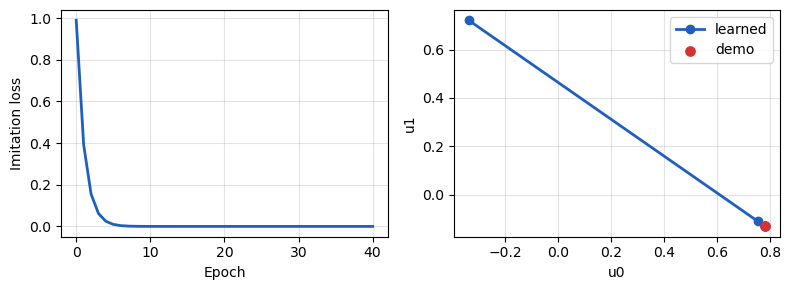

In [6]:
epochs_arr = np.array([h[0] for h in history])
loss_arr = np.array([h[1] for h in history])
viol_arr = np.array([h[2] for h in history])
sol_arr = np.vstack([h[4] for h in history])

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.0))
axes[0].plot(epochs_arr, loss_arr, color="#1f5fbf", lw=2.0)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Imitation loss")
axes[0].grid(True, alpha=0.35)

axes[1].plot(sol_arr[:, 0], sol_arr[:, 1], color="#1f5fbf", lw=2.0, marker="o", markevery=8, label="learned")
axes[1].scatter([demo[0]], [demo[1]], color="#d33333", s=45, label="demo", zorder=3)
axes[1].set_xlabel("u0")
axes[1].set_ylabel("u1")
axes[1].grid(True, alpha=0.35)
axes[1].legend(frameon=True)

plt.tight_layout()
print("final theta:", theta)
print("final loss:", loss_arr[-1])
print("final violation:", viol_arr[-1])